In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import scipy.special as sc
from scipy.integrate import odeint
import plotly.express as px
from tqdm import tqdm
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)

In [226]:
import warnings
warnings.filterwarnings('ignore') ### Not recommended, but a solution for some plot warnings for now.

In [222]:
### PFF vector:
def get_ab(fr):

    # Get a,b for beta cdf to compute lambda
    # fr < 0.5 needs a=1, b>a, from b=1 to b=top
    # b=top when fr = 0
    # b=1 when fr = 0.5
    # Linear relationship:   (0,top) -- (0.5,1) --> b= int(top - 2*(top-1)*fr)
    
    # fr > 0.5 needs a>b, b=1, from a=1 to a=10
    # a=1 when fr = 0.5
    # a=top when fr = 1
    # Linear relationship: (0.5, 1) -- (1, top) --> a = int(2*(top-1)*fr - top + 2)
    top1 = 5
    top2 = 10

    if fr < 0.5:
        a = 1
        b = int(top2 - 2*(top2-1)*fr)
    else:
        a = int(2*(top1-1)*fr - top1 + 2)
        b = 1

    return a, b

def getlambda(p00, M):
    a, b = get_ab(p00)
    pend = 0 # Minimum value of probability vector.
    ss = 2 # Offset to compute values of the vector.
    lambda_ = [sc.betainc(a, b, i/(M+ss))*(1-pend) + pend for i in range(1, M+1)]
    return lambda_

def getlambda2(p00, M, maxcr):
    c2 = p00
    xx = range(1, 2*maxcr+1)
    lambda_ = [1/(1+math.exp(-1*(1-p00)*(x-c2))) for x in xx]
    return lambda_

def solve_logistic_system(p_0, t_0, t_1, k, r):
    """
    Logistic Growth equation is deterministic
    We give the solution vector betweeen t0 and t1 .
    That is we return [P(t0), P(t1)] solution for the system:
        dP/dt = rP(1 - P/k)
        P(t0) = p
    The solution isÑ
    p(t) = kp_ 0 e^{r (t - t0)}/(k + p_ 0 (e^{r (t - t0)} - 1))
    We return p(t1)
    """
    result = (k*p_0*math.exp(r*(t_1-t_0)))/(k + p_0*(math.exp(r*(t_1-t_0)) - 1)) 
    return result


def chop(x, a, b):
    if x < a:
        return a
    elif x>=a and x<=b:
        return x
    elif x > b:
        return b

def fs(x,y,z,maxU):
    """
    Single peak function
    fs[x_,y_,z_]:=K(x z -z^2)^y
    Where K is computed such that the maximum value of fs equals max0.
    """
    return ((maxU*(4)**y)/(x**(2*y)))*((x*z - z**2)**y)

def fs2(x,y,z,maxU):
    """
    y := function shape, sensitivity
    x := symetry point, where the function reaches the 50 % value
    """
    x = x/4
    z_use = z
    if z >= 2*x:
        z_use = 4*x - z
    val_at_max = 1+math.exp(-1*y*(2*x-x))
    return val_at_max*maxU/(1+math.exp(-1*y*(z_use-x)))


def adaptive_decision(k, p0, estart, plan, disen, prt):
    # Decide foraging for this day and energy reserve at the end of day.
    # Maximizer code

    T = plan[0] # Time horizon
    Nu = plan[1] # Risk perception
    Delta = plan[2] # Delta from Bellman
    maxcr = plan[3]
    maxU = plan[4]

    cred = disen[0] # Activity reduction of infected ones due to symptoms severity
    iutred = disen[1] # Reduced utility obtained while infected

    b = maxcr*2
    ci = maxcr

    # Vector storaging the optimal s utility
    EUFF = [0]*(T+1)

    # The individual's goal is to remain suceptible by the end of the planning horizon, so cs=maxcr=12
    EUFF[-1] = fs(b, Nu, maxcr, maxU)

    # Vector storaging the optimal i utility
    EUNFF = [0]*(T+1)

    # Vector storaging the optimal contact rate for susceptible individuals
    cs = [0]*(T+1)

    # The last step is already known, the susceptible indivial wants to be susceptible at the end of the time horizon, 
    # then it is assumed that susceptible individuals have an optimized contact rate before the behavior change
    cs[-1] = maxcr

    # Optimization procedure

    # Finding Food Probabilities depending on foraging time
    Pffs = getlambda(p0/k, 2*maxcr)

    # Horizon times, this goes backwards
    for t in range(T-1, -1, -1):

        # if prt:
        #     print(f'{t}: ')
        #     utils = []
        #     pffs = []
        #     for csd in range(1, 2*maxcr+1):
        #         Pff = Pffs[csd-1]
        #         utils.append(cred*fs(b,Nu,csd,maxU))
        #         pffs.append(Delta*(Pff*EUFF[t+1] + (1-Pff)*EUNFF[t+1]))
        #     summ = [utils[k] + pffs[k] for k in range(len(utils))]
        #     plt.plot(range(1, len(utils)+1), utils, range(1, len(pffs)+1), pffs, range(1, len(summ)+1), summ)
        #     plt.show()

        # individual's utility starts at zero
        maxu = 0

        # Evaluating all the contact rates for susceptible individuals, all possible variable states
        for csd in range(1, 2*maxcr + 1):

            # Probability of finding food
            # Depends on the population size and foraging time
            Pff = Pffs[csd-1]

            # Evaluating the expected utilities

            # Utility gained by finding food
            EUFF_ = cred*fs(b,Nu,csd,maxU) + Delta*(Pff*EUFF[t+1] + (1-Pff)*EUNFF[t+1])

            # Utility gained by not finding food
            # This doesn't change!
            pnff = 1
            EUNFF[t] = iutred*fs(b,Nu,ci,maxU) + Delta*((1-pnff)*EUFF[t+1] + pnff*EUNFF[t+1])

            # Compare the new utility with the previous one, if it's bigger, then adapt the behavior
            if EUFF_ > maxu:
                cs[t] = csd
                maxu = EUFF_

        EUFF[t] = maxu

        # if prt:
        #     print(f'EUFF {EUFF[t]}, EUNFF {EUNFF[t]} at {t}. Selected cs: {cs[t]} {EUFF[t+1], EUNFF[t+1]}')

    return cs[0], fs(b, Nu, cs[0], maxU)


def adaptive_decision2(k, p0, estart, plan, disen, prt):
    # Decide foraging for this day and energy reserve at the end of day.
    # Maximizer code

    T = plan[0] # Time horizon
    Nu = plan[1] # Risk perception
    Delta = plan[2] # Delta from Bellman
    maxcr = plan[3]
    maxU = plan[4]

    cred = disen[0] # Activity reduction of infected ones due to symptoms severity
    iutred = disen[1] # Reduced utility obtained while infected

    b = maxcr*2
    ci = maxcr

    # Vector storaging the optimal s utility
    EUFF = [0]*(T+1)

    # The individual's goal is to remain suceptible by the end of the planning horizon, so cs=maxcr
    EUFF[-1] = fs2(b, Nu, maxcr, maxU)

    # Vector storaging the optimal i utility
    EUNFF = [0]*(T+1)

    # Vector storaging the optimal contact rate for susceptible individuals
    cs = [0]*(T+1)

    # The last step is already known, the susceptible indivial wants to be susceptible at the end of the time horizon, 
    # then it is assumed that susceptible individuals have an optimized contact rate before the behavior change
    cs[-1] = maxcr

    # Optimization procedure

    # Finding Food Probabilities depending on foraging time
    Pffs = getlambda(p0/k, 2*maxcr)

    # Horizon times, this goes backwards
    for t in range(T-1, -1, -1):

        if prt:
            print(f'{t}: ')
            utils = []
            pffs = []
            for csd in range(1, 2*maxcr+1):
                Pff = Pffs[csd-1]
                utils.append(cred*fs2(maxcr,Nu,csd,maxU))
                pffs.append(Delta*(Pff*EUFF[t+1] + (1-Pff)*EUNFF[t+1]))

            summ = [utils[k] + pffs[k] for k in range(len(utils))]
            plt.plot(range(1, len(utils)+1), utils, range(1, len(pffs)+1), pffs, range(1, len(summ)+1), summ)
            plt.show()

        # individual's utility starts at zero
        maxu = 0
        
        # Evaluating all the contact rates for susceptible individuals, all possible variable states
        for csd in range(1, 2*maxcr + 1):

            # Probability of finding food
            # Depends on the population size and foraging time
            Pff = Pffs[csd-1]

            # Evaluating the expected utilities

            # Utility gained by finding food
            EUFF_ = cred*fs2(b,Nu,csd,maxU) + Delta*(Pff*EUFF[t+1] + (1-Pff)*EUNFF[t+1])

            # Utility gained by not finding food
            # This doesn't change!
            pnff = 1
            EUNFF[t] = iutred*fs2(b,Nu,ci,maxU) + Delta*((1-pnff)*EUFF[t+1] + pnff*EUNFF[t+1])

            # Compare the new utility with the previous one, if it's bigger, then adapt the behavior
            if EUFF_ > maxu:
                cs[t] = csd
                maxu = EUFF_

        EUFF[t] = maxu

        if prt:
            print(f'EUFF {EUFF[t]}, EUNFF {EUNFF[t]} at {t}. Selected cs: {cs[t]} {EUFF[t+1], EUNFF[t+1]}')

    return cs[0], fs2(b, Nu, cs[0], maxU)

def adaptive_logistic(p_0, k, t_max, r_c, T, Nu, Delta, maxcr, maxU, cred, icred, **kwargs):

    # Decide wether to use classical model or adaptive
    adaptive = kwargs.get('adaptive', True)
    sigmoid = kwargs.get('sigmoid', False)
    p_vector = [p_0]

    energy_day = maxU # Initialize with max utility ---> With no adaptive the agent will choose the optimal foraging time always.
    foraging_day = maxcr
    r_day = r_c*energy_day

    energy_vector = []
    foraging_vector = []

    for t in range(t_max):

        # Solve the logistic for one day.
        p_range_day = solve_logistic_system(p_vector[-1], t, t+1, k, r_day)

        prt = False
        # if t == 70:
        #     prt = True

        if adaptive:

            fun_use = adaptive_decision
            if sigmoid:
                fun_use = adaptive_decision2
                
            foraging_day, energy_day = fun_use(
                k=k, p0=p_range_day,
                estart=energy_day, 
                plan=[T, Nu, Delta, maxcr, maxU],
                disen=[cred, icred], prt=prt)
                
            r_day = r_c*energy_day

        energy_vector.append(energy_day)
        foraging_vector.append(foraging_day)

        # Append solution for this day.
        p_vector.append(p_range_day)

    # Return all results
    return p_vector, energy_vector, foraging_vector

In [223]:
plt.rcParams["font.family"] = "Palatino Linotype"

#### Using conventional shape for utility function

5.0


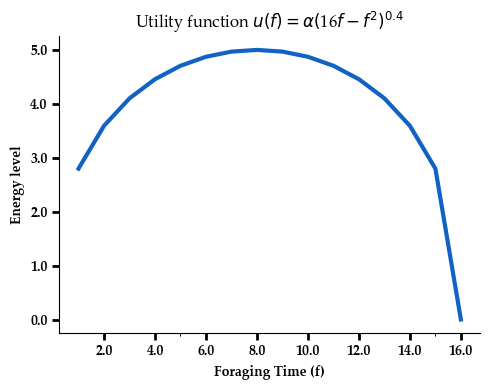

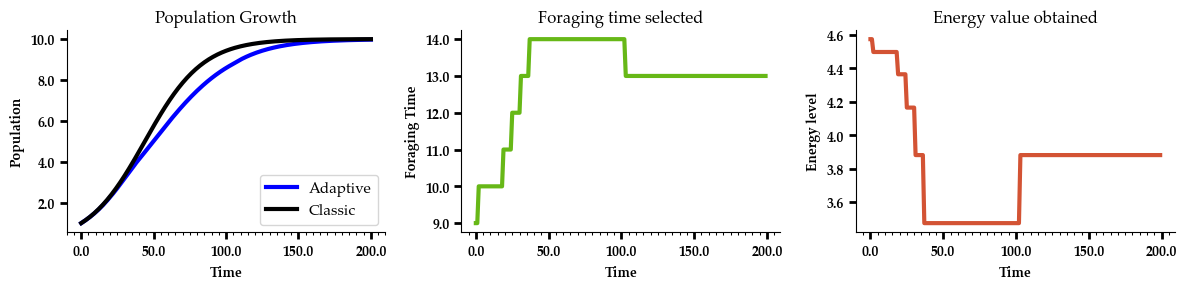

In [224]:
p_0 = 1
k = 10
t_max = 200
r_c = 0.01
T = 7
Delta = 0.98
maxcr = 8
maxU = 5
cred = 1
icred = 0.1
Nu = 0.4

p_vector0, energy_vector0, foraging_vector0 = adaptive_logistic(p_0, k, t_max, r_c, T, Nu, Delta, maxcr, maxU, cred, icred, adaptive=False)
p_vector, energy_vector, foraging_vector = adaptive_logistic(p_0, k, t_max, r_c, T, Nu, Delta, maxcr, maxU, cred, icred)

# Regular
utils = [fs(maxcr*2,Nu,csd,maxU) for csd in range(1, 2*maxcr + 1)]
print(np.max(utils))
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(5,4))
axs.plot(range(1, 2*maxcr + 1), utils, linewidth=3, color='#1162C3')
axs.set_title(r'Utility function $u(f)=\alpha ($'+f'{maxcr*2}'+f'$f - f^2)^{{{Nu}}}$', fontsize=12)
axs.tick_params(which='major', width=2.00, length=5)
axs.tick_params(which='minor', width=0.75, length=2.5)
axs.xaxis.set_minor_locator(MultipleLocator(5))
axs.spines['right'].set_visible(False)
axs.spines['top'].set_visible(False)
axs.set_xticklabels(axs.get_xticks(), weight='bold')
axs.set_yticklabels(axs.get_yticks().round(2), weight='bold')
axs.set_xlabel('Foraging Time (f)', fontsize=10, fontweight='bold')
axs.set_ylabel('Energy level', fontsize=10, fontweight='bold')
plt.tight_layout()
# plt.savefig('plots/UtilityFunctionExample.png')
plt.show()


fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12,3))

# Adaptive
axs[0].plot(range(len(p_vector)), p_vector, linewidth=3, label='Adaptive', color='blue')
axs[0].plot(range(len(p_vector0)), p_vector0, linewidth=3, label='Classic', color='black')
axs[0].set_title('Population Growth', fontsize=12)
axs[0].legend(prop={'size': 11}, loc='lower right')
axs[0].tick_params(which='major', width=2.00, length=5)
axs[0].tick_params(which='minor', width=0.75, length=2.5)
axs[0].xaxis.set_minor_locator(MultipleLocator(5))
axs[0].spines['right'].set_visible(False)
axs[0].spines['top'].set_visible(False)
axs[0].set_xticklabels(axs[0].get_xticks(), weight='bold')
axs[0].set_yticklabels(axs[0].get_yticks(), weight='bold')
axs[0].set_xlabel('Time', fontsize=10, fontweight='bold')
axs[0].set_ylabel('Population', fontsize=10, fontweight='bold')

axs[1].plot(range(len(foraging_vector)), foraging_vector, linewidth=3, color='#67B817')
axs[1].set_title('Foraging time selected', fontsize=12)
axs[1].tick_params(which='major', width=2.00, length=5)
axs[1].tick_params(which='minor', width=0.75, length=2.5)
axs[1].xaxis.set_minor_locator(MultipleLocator(5))
axs[1].spines['right'].set_visible(False)
axs[1].spines['top'].set_visible(False)
axs[1].set_xticklabels(axs[1].get_xticks(), weight='bold')
axs[1].set_yticklabels(axs[1].get_yticks().round(2), weight='bold')
axs[1].set_xlabel('Time', fontsize=10, fontweight='bold')
axs[1].set_ylabel('Foraging Time', fontsize=10, fontweight='bold')

axs[2].plot(range(len(energy_vector)), energy_vector, linewidth=3, color='#D35334')
axs[2].set_title('Energy value obtained', fontsize=12)
axs[2].tick_params(which='major', width=2.00, length=5)
axs[2].tick_params(which='minor', width=0.75, length=2.5)
axs[2].xaxis.set_minor_locator(MultipleLocator(5))
axs[2].spines['right'].set_visible(False)
axs[2].spines['top'].set_visible(False)
axs[2].set_xticklabels(axs[2].get_xticks(), weight='bold')
axs[2].set_yticklabels(axs[2].get_yticks().round(2), weight='bold')
axs[2].set_xlabel('Time', fontsize=10, fontweight='bold')
axs[2].set_ylabel('Energy level', fontsize=10, fontweight='bold')

plt.subplots_adjust(left=0.1,
                bottom=0.05,
                right=0.9, 
                top=1.5,
                wspace=0.4,
                hspace=0.4)
plt.tight_layout()
# plt.savefig(f'plots/PopGrowthAndFrgTime_{Nu}_{T}_{Delta}_{maxcr}_{cred}_{icred}_{maxU}_{r_c}_{k}.png')
plt.show()

#### Using a sigmoid shaped utility function

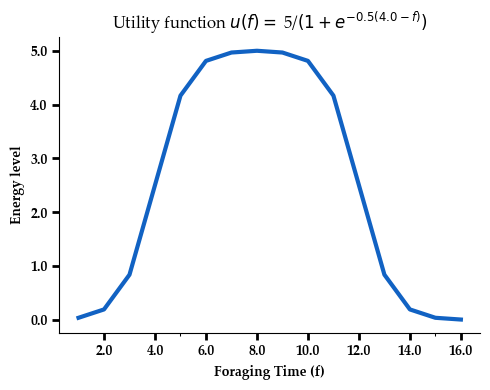

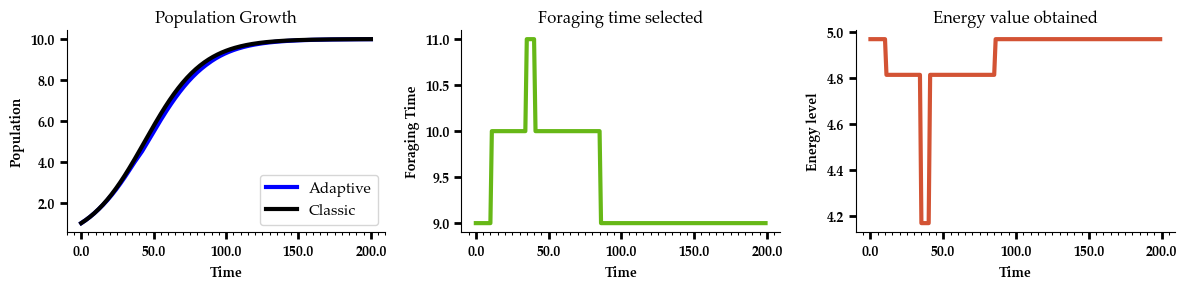

In [227]:
Nu = 1.6
p_vector0, energy_vector0, foraging_vector0 = adaptive_logistic(p_0, k, t_max, r_c, T, Nu, Delta, maxcr, maxU, cred, icred, adaptive=False)
p_vector, energy_vector, foraging_vector = adaptive_logistic(p_0, k, t_max, r_c, T, Nu, Delta, maxcr, maxU, cred, icred, sigmoid=True)

# Logistic
utils = [fs2(maxcr*2,Nu,csd,maxU) for csd in range(1, 2*maxcr + 1)]
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(5,4))
axs.plot(range(1, 2*maxcr + 1), utils, linewidth=3, color='#1162C3')
axs.set_title(r'Utility function $u(f)=$'+f' {maxU}/'+r'$(1+e^{-'+f'{NuR}'+r'('+f'{maxcr/2}'+r'-f)})$', fontsize=12)
axs.tick_params(which='major', width=2.00, length=5)
axs.tick_params(which='minor', width=0.75, length=2.5)
axs.xaxis.set_minor_locator(MultipleLocator(5))
axs.spines['right'].set_visible(False)
axs.spines['top'].set_visible(False)
axs.set_xticklabels(axs.get_xticks(), weight='bold')
axs.set_yticklabels(axs.get_yticks().round(2), weight='bold')
axs.set_xlabel('Foraging Time (f)', fontsize=10, fontweight='bold')
axs.set_ylabel('Energy level', fontsize=10, fontweight='bold')
plt.tight_layout()
# plt.savefig('plots/UtilityFunctionExampleSigmoid.png')
plt.show()

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12,3))

# Adaptive
axs[0].plot(range(len(p_vector)), p_vector, linewidth=3, label='Adaptive', color='blue')
axs[0].plot(range(len(p_vector0)), p_vector0, linewidth=3, label='Classic', color='black')
axs[0].set_title('Population Growth', fontsize=12)
axs[0].legend(prop={'size': 11}, loc='lower right')
axs[0].tick_params(which='major', width=2.00, length=5)
axs[0].tick_params(which='minor', width=0.75, length=2.5)
axs[0].xaxis.set_minor_locator(MultipleLocator(5))
axs[0].spines['right'].set_visible(False)
axs[0].spines['top'].set_visible(False)
axs[0].set_xticklabels(axs[0].get_xticks(), weight='bold')
axs[0].set_yticklabels(axs[0].get_yticks(), weight='bold')
axs[0].set_xlabel('Time', fontsize=10, fontweight='bold')
axs[0].set_ylabel('Population', fontsize=10, fontweight='bold')

axs[1].plot(range(len(foraging_vector)), foraging_vector, linewidth=3, color='#67B817')
axs[1].set_title('Foraging time selected', fontsize=12)
axs[1].tick_params(which='major', width=2.00, length=5)
axs[1].tick_params(which='minor', width=0.75, length=2.5)
axs[1].xaxis.set_minor_locator(MultipleLocator(5))
axs[1].spines['right'].set_visible(False)
axs[1].spines['top'].set_visible(False)
axs[1].set_xticklabels(axs[1].get_xticks(), weight='bold')
axs[1].set_yticklabels(axs[1].get_yticks().round(2), weight='bold')
axs[1].set_xlabel('Time', fontsize=10, fontweight='bold')
axs[1].set_ylabel('Foraging Time', fontsize=10, fontweight='bold')

axs[2].plot(range(len(energy_vector)), energy_vector, linewidth=3, color='#D35334')
axs[2].set_title('Energy value obtained', fontsize=12)
axs[2].tick_params(which='major', width=2.00, length=5)
axs[2].tick_params(which='minor', width=0.75, length=2.5)
axs[2].xaxis.set_minor_locator(MultipleLocator(5))
axs[2].spines['right'].set_visible(False)
axs[2].spines['top'].set_visible(False)
axs[2].set_xticklabels(axs[2].get_xticks(), weight='bold')
axs[2].set_yticklabels(axs[2].get_yticks().round(2), weight='bold')
axs[2].set_xlabel('Time', fontsize=10, fontweight='bold')
axs[2].set_ylabel('Energy level', fontsize=10, fontweight='bold')

plt.subplots_adjust(left=0.1,
                bottom=0.05,
                right=0.9, 
                top=1.5,
                wspace=0.4,
                hspace=0.4)
plt.tight_layout()
# plt.savefig(f'plots/PopGrowthAndFrgTime_{Nu}_{T}_{Delta}_{maxcr}_{cred}_{icred}_{maxU}_{r_c}_{k}_Sigmoid.png')
plt.show()

### Note: PFF vector shape
Changing the `getlambda` function affects greatly the results of the method. \
Go ahead and change `pend` and `ss` parameters below to overwrite this function, rerun previous cells and see how the simulations in previous plots change.

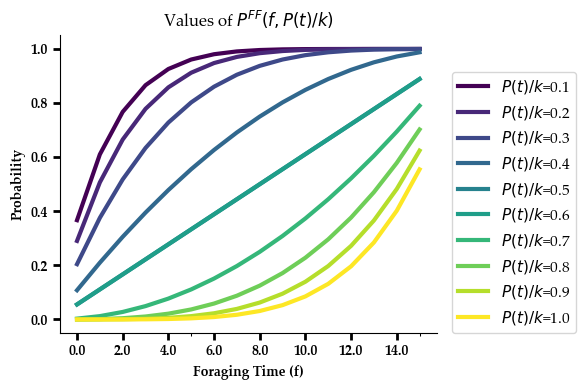

In [225]:
def getlambda(p00, M):
    a, b = get_ab(p00)
    pend = 0.8 # Minimum value of probability vector.
    ss = 2 # Offset to compute values of the vector.
    lambda_ = [sc.betainc(a, b, i/(M+ss))*(1-pend) + pend for i in range(1, M+1)]
    return lambda_

M=maxcr*2
colors = px.colors.sequential.Viridis

fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(6,4))
for idx, pp in enumerate(np.linspace(0.1,1,10)):
    lambda_ = getlambda(pp, M=maxcr*2)
    axs.plot(range(M), lambda_, color=colors[idx], linewidth=3, label=r'$P(t)/k$'+f'={round(pp,2)}')

axs.set_title(r'Values of $P^{FF}(f, P(t)/k)$', fontsize=12)
axs.legend(prop={'size': 11}, loc=(1.04, 0))
axs.tick_params(which='major', width=2.00, length=5)
axs.tick_params(which='minor', width=0.75, length=2.5)
axs.xaxis.set_minor_locator(MultipleLocator(5))
axs.spines['right'].set_visible(False)
axs.spines['top'].set_visible(False)
axs.set_xticklabels(axs.get_xticks(), weight='bold')
axs.set_yticklabels(axs.get_yticks().round(2), weight='bold')
axs.set_xlabel('Foraging Time (f)', fontsize=10, fontweight='bold')
axs.set_ylabel('Probability', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/ProbFindingFoodPerPop.png')
plt.show()

Another option for the $PFF$ vector can be the use of sigmoid functions!

## Sensitivity analysis

### Limits vs $\nu$:

In [207]:
p_0 = 1
k = 10
t_max = 500
r_c = 0.01
T = 14
Delta = 0.98
maxcr = 8
maxU = 5
cred = 1
icred = 0.1

Nu_vector = np.linspace(0.25, 2, 50)

limit_foraging = []
limit_energy = []
for Nu in tqdm(Nu_vector):
    p_vector, energy_vector, foraging_vector = adaptive_logistic(p_0, k, t_max, r_c, T, Nu, Delta, maxcr, maxU, cred, icred)
    limit_foraging.append(foraging_vector[-1])
    limit_energy.append(energy_vector[-1])

100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [00:21<00:00,  2.33it/s]


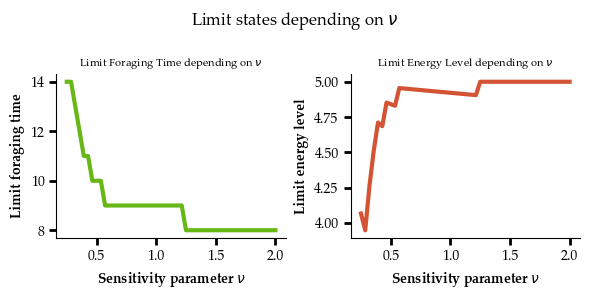

In [208]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(6,3))

# Adaptive
axs[0].plot(Nu_vector, limit_foraging, linewidth=3, color='#67B817')
axs[0].set_title(r'Limit Foraging Time depending on $\nu$', fontsize=8)
axs[0].tick_params(which='major', width=2.00, length=5)
axs[0].tick_params(which='minor', width=0.75, length=2.5)
axs[0].xaxis.set_minor_locator(MultipleLocator(5))
axs[0].spines['right'].set_visible(False)
axs[0].spines['top'].set_visible(False)
axs[0].set_xlabel(r'Sensitivity parameter $\nu$', fontsize=10, fontweight='bold')
axs[0].set_ylabel('Limit foraging time', fontsize=10, fontweight='bold')


axs[1].plot(Nu_vector, limit_energy, linewidth=3, color='#D35334')
axs[1].set_title(r'Limit Energy Level depending on $\nu$', fontsize=8)
axs[1].tick_params(which='major', width=2.00, length=5)
axs[1].tick_params(which='minor', width=0.75, length=2.5)
axs[1].xaxis.set_minor_locator(MultipleLocator(5))
axs[1].spines['right'].set_visible(False)
axs[1].spines['top'].set_visible(False)
axs[1].set_xlabel(r'Sensitivity parameter $\nu$', fontsize=10, fontweight='bold')
axs[1].set_ylabel('Limit energy level', fontsize=10, fontweight='bold')

plt.subplots_adjust(left=0.1,
                bottom=0.05,
                right=0.9, 
                top=1.5,
                wspace=0.4,
                hspace=0.4)

fig.suptitle(r'Limit states depending on $\nu$')
plt.tight_layout()
plt.savefig('plots/LimitsDependingOnNu.png')
plt.show()

### Difference between adaptive and classic vs $\nu$:

100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [00:24<00:00,  2.06it/s]


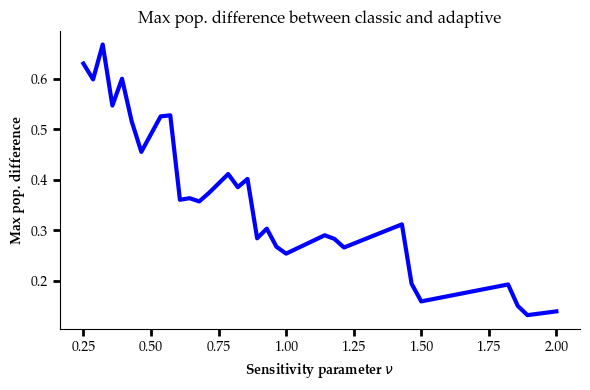

In [209]:
difference_vector = []
for Nu in tqdm(Nu_vector):
    p_vector0, energy_vector0, foraging_vector0 = adaptive_logistic(p_0, k, t_max, r_c, T, Nu, Delta, maxcr, maxU, cred, icred, adaptive=False)
    p_vector, energy_vector, foraging_vector = adaptive_logistic(p_0, k, t_max, r_c, T, Nu, Delta, maxcr, maxU, cred, icred)
    diffs = [p_vector0[i]-p_vector[i] for i in range(len(p_vector0))]
    max_diff = np.max(diffs)
    difference_vector.append(max_diff)

fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(6,4))
axs.plot(Nu_vector, difference_vector, color='blue', linewidth=3)
axs.set_title('Max pop. difference between classic and adaptive', fontsize=12)
axs.tick_params(which='major', width=2.00, length=5)
axs.tick_params(which='minor', width=0.75, length=2.5)
axs.xaxis.set_minor_locator(MultipleLocator(5))
axs.spines['right'].set_visible(False)
axs.spines['top'].set_visible(False)
axs.set_xlabel(r'Sensitivity parameter $\nu$', fontsize=10, fontweight='bold')
axs.set_ylabel('Max pop. difference', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/DifferenceWithClassicDependingOnNu.png')
plt.show()

### Difference between adaptive and classical depending on $\tau$

In [210]:
Nu = 0.5
T_vector = range(1,100)
difference_vector = []
for T in tqdm(T_vector):
    p_vector0, energy_vector0, foraging_vector0 = adaptive_logistic(p_0, k, t_max, r_c, T, Nu, Delta, maxcr, maxU, cred, icred, adaptive=False)
    p_vector, energy_vector, foraging_vector = adaptive_logistic(p_0, k, t_max, r_c, T, Nu, Delta, maxcr, maxU, cred, icred)
    diffs = [p_vector0[i]-p_vector[i] for i in range(len(p_vector0))]
    max_diff = np.max(diffs)
    difference_vector.append(max_diff)

100%|██████████████████████████████████████████████████████████████████████████████████| 99/99 [01:50<00:00,  1.12s/it]


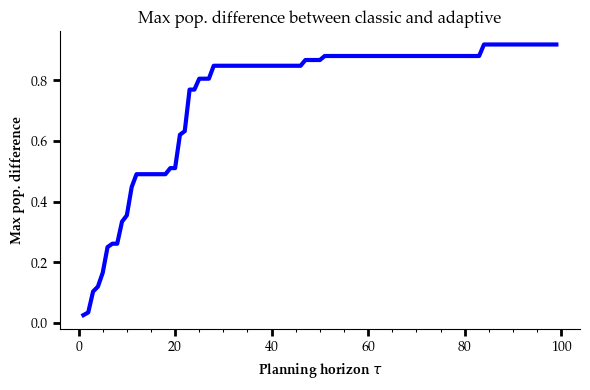

In [211]:
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(6,4))
axs.plot(list(T_vector), difference_vector, color='blue', linewidth=3)
axs.set_title('Max pop. difference between classic and adaptive', fontsize=12)
axs.tick_params(which='major', width=2.00, length=5)
axs.tick_params(which='minor', width=0.75, length=2.5)
axs.xaxis.set_minor_locator(MultipleLocator(5))
axs.spines['right'].set_visible(False)
axs.spines['top'].set_visible(False)
axs.set_xlabel(r'Planning horizon $\tau$', fontsize=10, fontweight='bold')
axs.set_ylabel('Max pop. difference', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/DifferenceWithClassicDependingOnTau.png')
plt.show()

### Creating sigmoid utility function

4.999425138747062


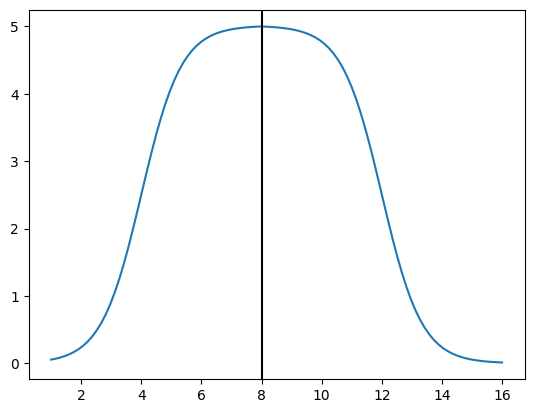

In [159]:
maxcr = 8
range_ = np.linspace(1, maxcr*2, 100)
Nu = 1.5
utils = [fs2(maxcr*2,Nu,z,maxU) for z in range_]
print(np.max(utils))
plt.plot(range_, utils)
plt.axvline(x=maxcr, color='black')
plt.show()